# Preparing Insight data for PIConGPU

## Intro
This notebook allows you to manipulate Insight data and prepare it to be read via the InsightPulse profile into PIconGPU.
The raw Insight data cannot be used, since it (at least) has to be phase corrected and transformed into the time domain. 
Furthermore, the field can be propagated.

## Load modules

In [1]:
# standard modules
import numpy as np
import matplotlib.pyplot as plt

# modules from preparingInsightData.py
from preparingInsightData import preproutines

## Get the data
The far field data from an Insight measurement is stored in a h5 file. What we first do is:
1. read the far field data and store it in numpy arrays
2. fit the far field data intensity with a 2D gaussian to extract the beam center and waist size
3. propagate to the near field
4. fit the near field data with a 2D supergaussian to extract the beam center and waist size

In [2]:
insight = preproutines("/bigdata/hplsim/production/dietri04/Masterarbeit/", "Exyw_FF.h5", 2000)

Central wavelength: 796 nm
Rayleigh length: zR = 1.28 mm
Far field center coordinates: xc = 3.36 um, yc = 3.30 um
Far field waist size: w = 18.04 um
Near field center coordinates: xc = 22.71 mm, yc = 2.60 mm
Near field waist size: w = 42.65 mm


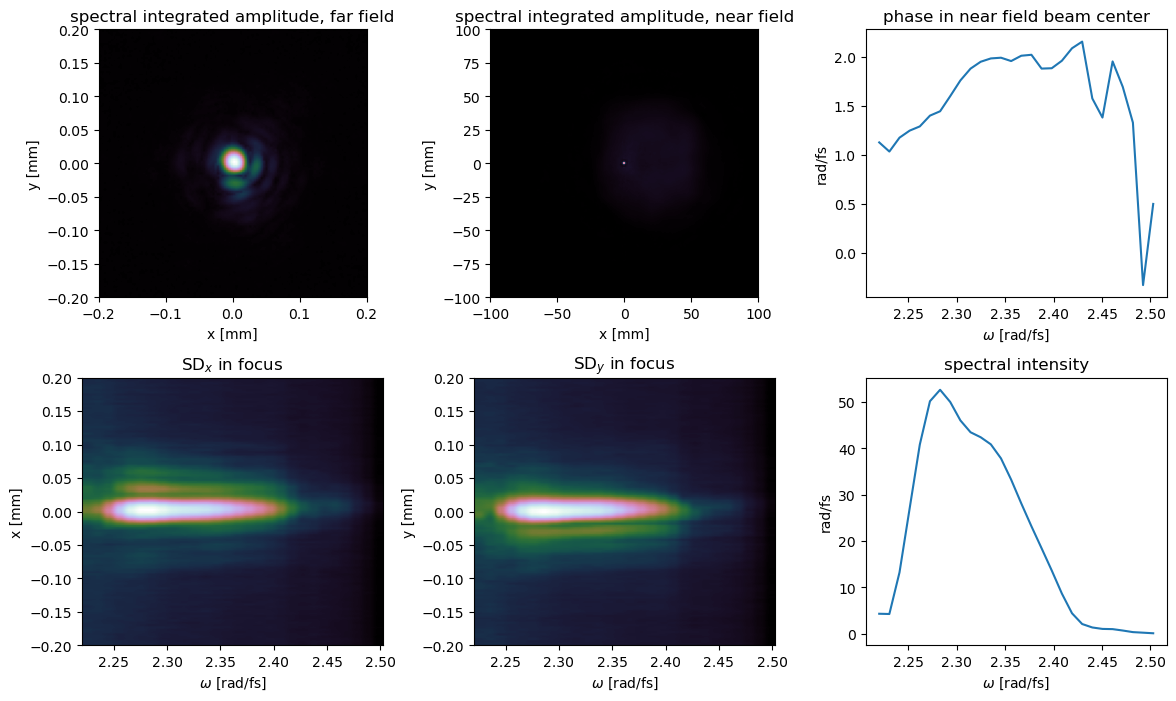

In [3]:
# some nice colorful pictures of our data
fig = plt.figure(figsize=(14, 8))

ax1 = fig.add_subplot(231)
ax1.imshow(np.sum(np.abs(insight.Ew), axis=-1), cmap='cubehelix', origin='lower', extent=(insight.x[0], insight.x[-1], insight.y[0], insight.y[-1]))
ax1.set_title("spectral integrated amplitude, far field")
ax1.set_xlabel("x [mm]")
ax1.set_ylabel("y [mm]")
ax1.set_xlim(-.2, .2)
ax1.set_ylim(-.2, .2)

ax2 = fig.add_subplot(232)
ax2.imshow(np.sum(np.abs(insight.Ew_NF), axis=-1), cmap='cubehelix', origin='lower', extent=(insight.x_NF[0], insight.x_NF[-1], insight.y_NF[0], insight.y_NF[-1]))
ax2.set_title("spectral integrated amplitude, near field")
ax2.set_xlabel("x [mm]")
ax2.set_ylabel("y [mm]")
ax2.set_xlim(-100, 100)
ax2.set_ylim(-100, 100)

ax3 = fig.add_subplot(233)
ax3.plot(insight.w, np.angle(insight.Ew_NF[np.abs(insight.y_NF - insight.yc_NF).argmin(), np.abs(insight.x_NF - insight.xc_NF).argmin(), :]))
ax3.set_title("phase in near field beam center")
ax3.set_xlabel(r"$\omega$ [rad/fs]")
ax3.set_ylabel("rad/fs")

ax4 = fig.add_subplot(234)
ax4.imshow(np.sum(np.abs(insight.Ew), axis=0), cmap='cubehelix', origin='lower', aspect='auto', extent=(insight.w[0], insight.w[-1], insight.x[0], insight.x[-1]))
ax4.set_title(r"SD$_x$ in focus")
ax4.set_ylabel("x [mm]")
ax4.set_xlabel(r"$\omega$ [rad/fs]")
ax4.set_ylim(-.2, .2)

ax5 = fig.add_subplot(235)
ax5.imshow(np.sum(np.abs(insight.Ew), axis=1), cmap='cubehelix', origin='lower', aspect='auto', extent=(insight.w[0], insight.w[-1], insight.x[0], insight.x[-1]))
ax5.set_title(r"SD$_y$ in focus")
ax5.set_xlabel(r"$\omega$ [rad/fs]")
ax5.set_ylabel("y [mm]")
ax5.set_ylim(-.2, .2)

ax6 = fig.add_subplot(236)
# sum just over the main beam spot to extract the spectrum
ax6.plot(insight.w, np.sum(np.sum(np.abs(insight.Ew[np.abs(insight.y - insight.yc + 2*insight.waist).argmin():np.abs(insight.y - insight.yc - 2*insight.waist).argmin(),\
                                                    np.abs(insight.x - insight.xc + 2*insight.waist).argmin():np.abs(insight.x - insight.xc - 2*insight.waist).argmin(),\
                                                    :])**2, axis=0), axis=0))
ax6.set_title("spectral intensity")
ax6.set_xlabel(r"$\omega$ [rad/fs]")
ax6.set_ylabel("rad/fs")

plt.subplots_adjust(hspace=.3, wspace=.3)
plt.show()

## Correct the data
### Adjust beam compression and add dispersion parameters
Before we go on with any calculations, we have to correct the phase. Insight reconstructs the amplitude of the far field beam aswell as the phase, up to a unknown global phase for every frequency.
For an estimation of this global phase, we assume perfect compression in the (near field) beam center. Thus, we extract the phase in the beam center in dependence of the frequency and substract this function globally (i.e. from the measured phase in dependence of the frequency at every space point).
Here, we also have the possibility to add dispersion parameters such as group velocity dispersion (GVD) and third order dispersion (TOD) (both are set to 0 by default).

In [4]:
insight.correctPhase()

Phase has been corrected. 
Applied dispersion parameters: GVD = 0 fs**2/rad, TOD = 0 fs**3/rad**2


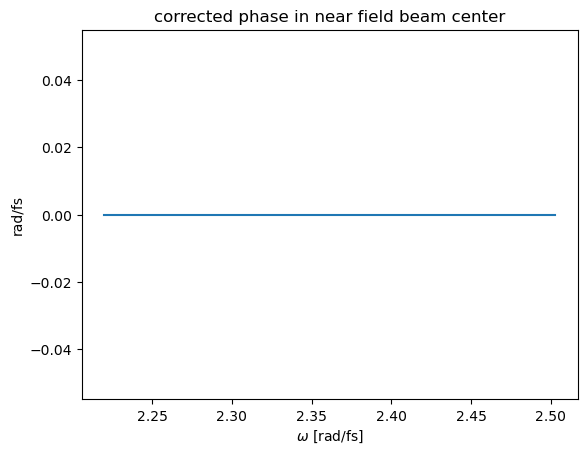

In [5]:
plt.plot(insight.w, np.angle(insight.Ew_NF[np.abs(insight.y_NF - insight.yc_NF).argmin(), np.abs(insight.x_NF - insight.xc_NF).argmin(), :]))
plt.title("corrected phase in near field beam center")
plt.xlabel(r"$\omega$ [rad/fs]")
plt.ylabel("rad/fs")
plt.show()

### Correct ugly spots in the near field (optional)
Sometimes, the amplitude in the near field looks weird, showing some (unphysical) peaks or holes. These can cause artefacts in the far field and can thus be smoothened out.

In [6]:
insight.correctUglySpotInNF(0.0, 0.0)

corrected ugly spot in near field at x = 0.00 mm, y = 0.00 mm


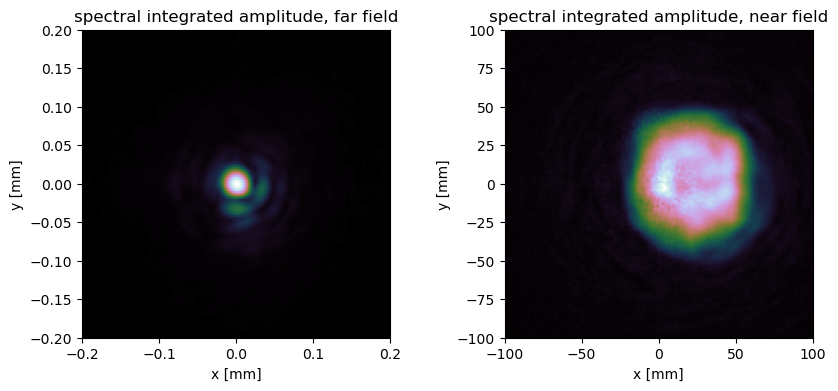

In [7]:
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(121)
ax1.imshow(np.sum(np.abs(insight.Ew), axis=-1), cmap='cubehelix', origin='lower', extent=(insight.x[0], insight.x[-1], insight.y[0], insight.y[-1]))
ax1.set_title("spectral integrated amplitude, far field")
ax1.set_xlabel("x [mm]")
ax1.set_ylabel("y [mm]")
ax1.set_xlim(-.2, .2)
ax1.set_ylim(-.2, .2)

ax2 = fig.add_subplot(122)
ax2.imshow(np.sum(np.abs(insight.Ew_NF), axis=-1), cmap='cubehelix', origin='lower', extent=(insight.x_NF[0], insight.x_NF[-1], insight.y_NF[0], insight.y_NF[-1]))
ax2.set_title("spectral integrated amplitude, near field")
ax2.set_xlabel("x [mm]")
ax2.set_ylabel("y [mm]")
ax2.set_xlim(-100, 100)
ax2.set_ylim(-100, 100)

plt.show()

### Center the near field beam spot (optional)
When the near field beam spot is not centered (please check the center coordinates above), the far field will propagate obliquely instead of straight ahead. Centering the near field prevents this.

In [8]:
insight.shiftNFtoCenter()

21 2
shifted the near field into the center by x = 22.92 mm, y = 2.18 mm


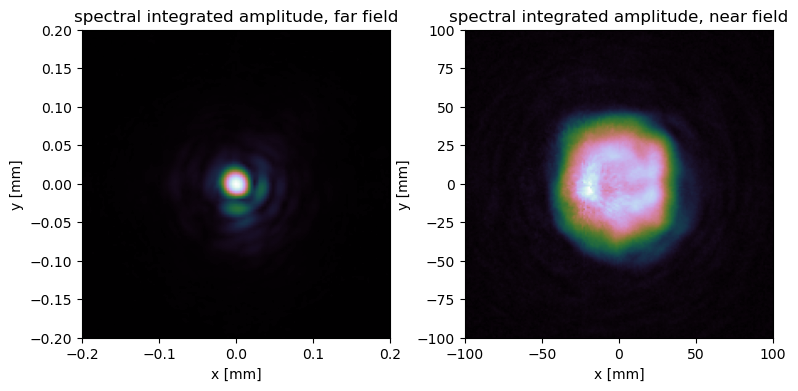

In [9]:
fig = plt.figure(figsize=(14, 4))

ax1 = fig.add_subplot(131)
ax1.imshow(np.sum(np.abs(insight.Ew), axis=-1), cmap='cubehelix', origin='lower', extent=(insight.x[0], insight.x[-1], insight.y[0], insight.y[-1]))
ax1.set_title("spectral integrated amplitude, far field")
ax1.set_xlabel("x [mm]")
ax1.set_ylabel("y [mm]")
ax1.set_xlim(-.2, .2)
ax1.set_ylim(-.2, .2)

ax2 = fig.add_subplot(132)
ax2.imshow(np.sum(np.abs(insight.Ew_NF), axis=-1), cmap='cubehelix', origin='lower', extent=(insight.x_NF[0], insight.x_NF[-1], insight.y_NF[0], insight.y_NF[-1]))
ax2.set_title("spectral integrated amplitude, near field")
ax2.set_xlabel("x [mm]")
ax2.set_ylabel("y [mm]")
ax2.set_xlim(-100, 100)
ax2.set_ylim(-100, 100)
plt.show()

## Propagate
Now the far field data is ready to be propagated. For that, the angular spectrum method is used, which means that one cannot propagate too far, since then the growing beam diameter could reach the transversal window borders and thus cause fourier transform artefacts due to the usage of the fft2 algorithm.

In [11]:
z = -19  # mm
Ew_prop = insight.propagate(z)

far field propagated to z = -19.00 mm


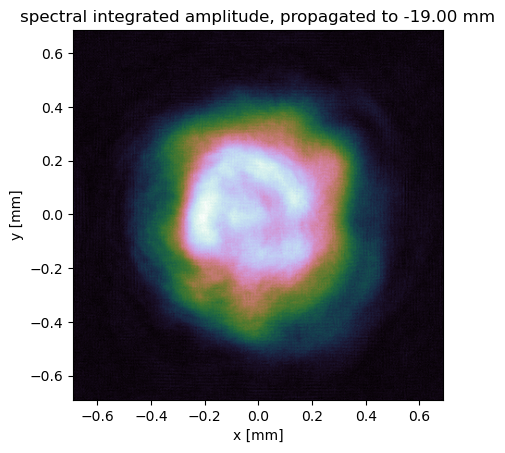

In [12]:
plt.imshow(np.sum(np.abs(Ew_prop), axis=-1), cmap='cubehelix', origin='lower', extent=(insight.x[0], insight.x[-1], insight.y[0], insight.y[-1]))
plt.title("spectral integrated amplitude, propagated to %.2f mm"%(z))
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
#plt.xlim(-.2, .2)
#plt.ylim(-.2, .2)
plt.show()

## Transform to the time domain
The far field data is transformed to the time domain via the fft algorithm. This takes a while, since the spectrum has to be extended and the field data extrapolated.

In [12]:
insight.toTimeDomain(Ew_prop, 8)

field data size: 2.3 GB


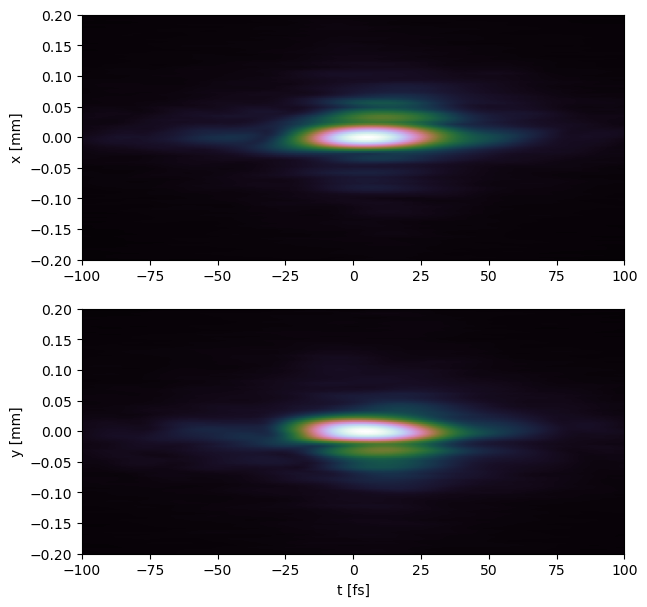

In [13]:
fig = plt.figure(figsize=(7, 7))

ax1 = fig.add_subplot(211)
ax1.imshow(np.sum(np.abs(insight.Et), axis=0), cmap='cubehelix', origin='lower', aspect='auto', extent=(insight.t[0], insight.t[-1], insight.x[0], insight.x[-1]))
ax1.set_ylabel("x [mm]")
ax1.set_xlim(-100, 100)
ax1.set_ylim(-.2, .2)

ax2 = fig.add_subplot(212)
ax2.imshow(np.sum(np.abs(insight.Et), axis=1), cmap='cubehelix', origin='lower', aspect='auto', extent=(insight.t[0], insight.t[-1], insight.x[0], insight.x[-1]))
ax2.set_xlabel("t [fs]")
ax2.set_ylabel("y [mm]")
ax2.set_xlim(-100, 100)
ax2.set_ylim(-.2, .2)

plt.show()

## Save data to OpenPMD
The data is now nearly ready to use it as InsightPulse input. We still have to correct the amplitude of the pulse in the time domain (= scaling to the actual beam energy, given in Joule) and save it to an OpenPMD checkpoint. Furthermore, the field data chunk may still be too big: the whole chunk will be stored on the GPUs afterwards, but their memory is limited.
The following function corrects the amplitude by scaling to the actual beam enregy and allows cropping the borders of the field data chunk before saving it at the given destination path.

In [14]:
insight.saveToOpenPMD("", "insightData_300um%T.h5", energy=4.5, crop_x=0.3, crop_y=0.3, crop_t=100)

data successfully saved, field data size: 493 MB
